In [1]:
# Import necessary libraries for date and time manipulation, timezone handling, and displaying formatted text in a notebook
from datetime import datetime
from pytz import timezone
from IPython.display import display, Markdown, HTML

# Track the time when the first cell is executed
first_cell_time = datetime.now()

# Set IST timezone (Indian Standard Time)
ist = timezone('Asia/Kolkata')

# Get the current time in IST for the first cell entry
current_time_ist_first = datetime.now(ist).strftime('%Y-%m-%d %H:%M:%S')

# Display the statement "This is the first cell" in green and bold
display(HTML("<p style='color:green; font-weight:bold;'>This is the first cell. Initialization and setup are done below:</p>"))

# Display the current IST time for the first cell in bold (default color)
display(Markdown(f'**First Cell Entry Time: {current_time_ist_first}**'))


**First Cell Entry Time: 2026-06-03 17:35:36**

# Introduction

- Instagram is one of the most popular social media applications today. People using Instagram professionally are using it for promoting their business, building a portfolio, blogging, and creating various kinds of content. As Instagram is a popular application used by millions of people with different niches, Instagram keeps changing to make itself better for content creators and users. But as this keeps changing, it affects the reach of our posts which affects us in the long run. So if content creator wants to do well on Instagram in the long run, they have to look at the data of their Instagram reach. That is where the use of Data Science in social media comes in.

- I have been researching Instagram reach for a long time. Every time I post on my Instagram account, I collect data about how successful the post is after a week. This helps to understand how the Instagram algorithm works. If you want to analyze the reach of your Instagram account, you have to collect your data manually because there are some APIs, but they don't work well. Therefore, it is better to collect your Instagram data manually.

- If you want to learn how to analyze Instagram reach using Python, you can use the data I collected from my Instagram account. You can download the dataset I used to analyze Instagram reach [here](https://statso.io/wp-content/uploads/2022/10/archive.zip).

# Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
from sklearn.model_selection import train_test_split
from sklearn.linear_model import PassiveAggressiveRegressor
from tabulate import tabulate


In [4]:
# Check if tabulate is installed
try:
    import tabulate
    print("Tabulate is installed.")
except ImportError:
    print("Tabulate is not installed. Installing now...")
    !pip install tabulate
    import tabulate
    print("Tabulate has been installed.")


Tabulate is installed.


# Read Data

In [6]:
import pandas as pd

# Load the data into a DataFrame
data = pd.read_csv("https://raw.githubusercontent.com/9394113857/Data-Sets/adb55724afe7963735b3f1f4512d0024881b4fe5/Instagram%20data.csv", encoding='latin1')



In [8]:
from tabulate import tabulate

# Print the first few rows of the DataFrame using tabulate
print(tabulate(data.head(), headers='keys', tablefmt='grid'))


+----+---------------+-------------+-----------------+----------------+--------------+---------+------------+----------+---------+------------------+-----------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|    |   Impressions |   From Home |   From Hashtags |   From Explore |   From Other |   Saves |   Comments |   Shares |   Likes |   Profile Visits |   Follows | Caption                                                                                                      

In [9]:
print(data.head())

   Impressions  From Home  From Hashtags  From Explore  From Other  Saves  \
0         3920       2586           1028           619          56     98   
1         5394       2727           1838          1174          78    194   
2         4021       2085           1188             0         533     41   
3         4528       2700            621           932          73    172   
4         2518       1704            255           279          37     96   

   Comments  Shares  Likes  Profile Visits  Follows  \
0         9       5    162              35        2   
1         7      14    224              48       10   
2        11       1    131              62       12   
3        10       7    213              23        8   
4         5       4    123               8        0   

                                             Caption  \
0  Here are some of the most important data visua...   
1  Here are some of the best data science project...   
2  Learn how to train a machine learni

# Whether the dataset contains null values or not

In [10]:
data.isnull().sum()

,0
Impressions,0
From Home,0
From Hashtags,0
From Explore,0
From Other,0
Saves,0
Comments,0
Shares,0
Likes,0
Profile Visits,0


In [11]:
data = data.dropna()

# Look at the insights of the columns to understand the data type of all the columns:

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119 entries, 0 to 118
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Impressions     119 non-null    int64 
 1   From Home       119 non-null    int64 
 2   From Hashtags   119 non-null    int64 
 3   From Explore    119 non-null    int64 
 4   From Other      119 non-null    int64 
 5   Saves           119 non-null    int64 
 6   Comments        119 non-null    int64 
 7   Shares          119 non-null    int64 
 8   Likes           119 non-null    int64 
 9   Profile Visits  119 non-null    int64 
 10  Follows         119 non-null    int64 
 11  Caption         119 non-null    object
 12  Hashtags        119 non-null    object
dtypes: int64(11), object(2)
memory usage: 12.2+ KB


# Analyzing Instagram Reach

- Let’s start with analyzing the reach of my Instagram posts.
- I will first have a look at the distribution of impressions I have received from home.

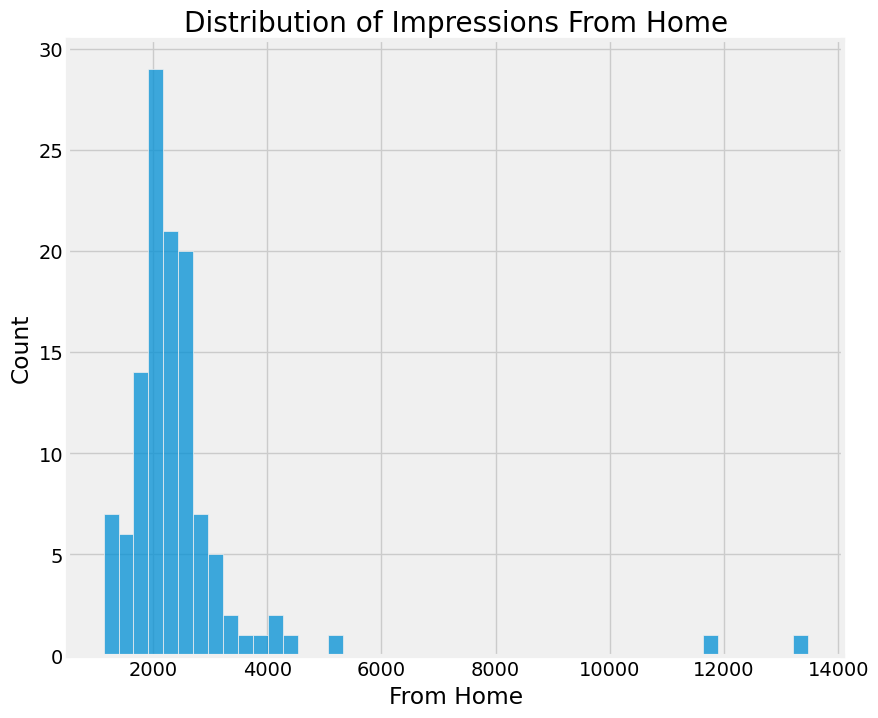

In [13]:
plt.figure(figsize=(10, 8))
plt.style.use('fivethirtyeight')
plt.title("Distribution of Impressions From Home")
#sns.distplot(data['From Home'])
sns.histplot(data['From Home'])
plt.show()

# Impression

- The impressions I get from the home section on Instagram shows how much my posts reach my followers.

- Looking at the impressions from home, I can say it’s hard to reach all my followers daily.

- Now let’s have a look at the distribution of the impressions I received from hashtags:

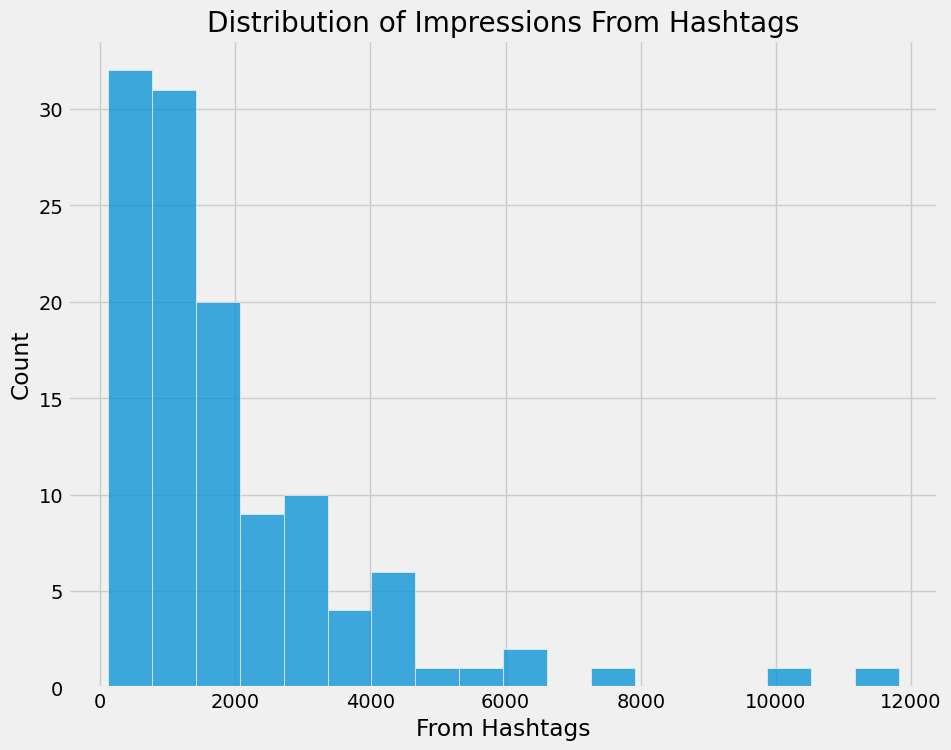

In [14]:
plt.figure(figsize=(10, 8))
plt.title("Distribution of Impressions From Hashtags")
#sns.distplot(data['From Hashtags'])
sns.histplot(data['From Hashtags'])
plt.show()

# Hashtag

- Hashtags are tools we use to categorize our posts on Instagram so that we can reach more people based on the kind of content we are creating.

- Looking at hashtag impressions shows that not all posts can be reached using hashtags, but many new users can be reached from hashtags.

- Now let’s have a look at the distribution of impressions I have received from the explore section of Instagram:

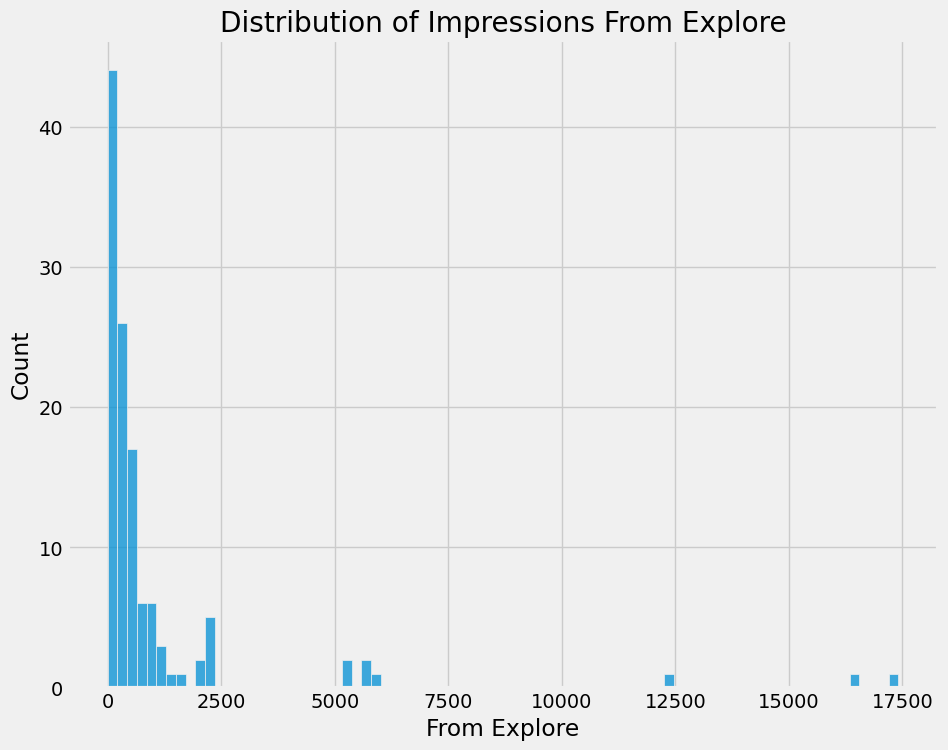

In [15]:
plt.figure(figsize=(10, 8))
plt.title("Distribution of Impressions From Explore")
#sns.distplot(data['From Explore'])
sns.histplot(data['From Explore'])
plt.show()

- The explore section of Instagram is the recommendation system of Instagram. It recommends posts to users based on their preferences and interests.

- By looking at the impressions I have received from the explore section, I can say that Instagram does not recommend our posts much to the users. Some posts have received a good reach from the explore section, but it’s still very low compared to the reach I receive from hashtags.

- Let’s have a look at the percentage of impressions I get from various sources on Instagram:

In [16]:
home = data["From Home"].sum()
hashtags = data["From Hashtags"].sum()
explore = data["From Explore"].sum()
other = data["From Other"].sum()

labels = ['From Home','From Hashtags','From Explore','Other']
values = [home, hashtags, explore, other]

fig = px.pie(data, values=values, names=labels,
             title='Impressions on Instagram Posts From Various Sources', hole=0.5)
fig.show()

#### So the above donut plot shows that almost 45 percent of the reach is from my followers, 33.6 percent is from hashtags, 19.2 percent is from the explore section, and 3.05 percent is from other sources.

# Analyzing Content

- Let’s analyze the content of my Instagram posts. The dataset has two columns, namely caption, and hashtags, which will help us understand the kind of content I post on Instagram.

- Let’s create a wordcloud of the caption column to look at the most used words in the caption of my Instagram posts:

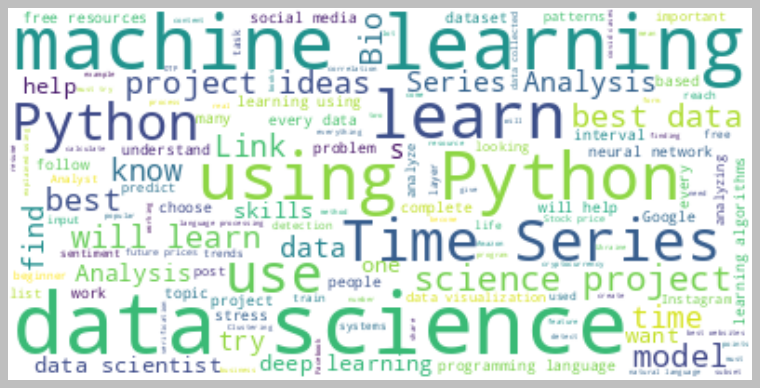

In [17]:
text = " ".join(i for i in data.Caption)
stopwords = set(STOPWORDS)
wordcloud = WordCloud(stopwords=stopwords, background_color="white").generate(text)
plt.style.use('classic')
plt.figure( figsize=(12,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

- Let’s create a wordcloud of the hashtags column to look at the most used hashtags in my Instagram posts:

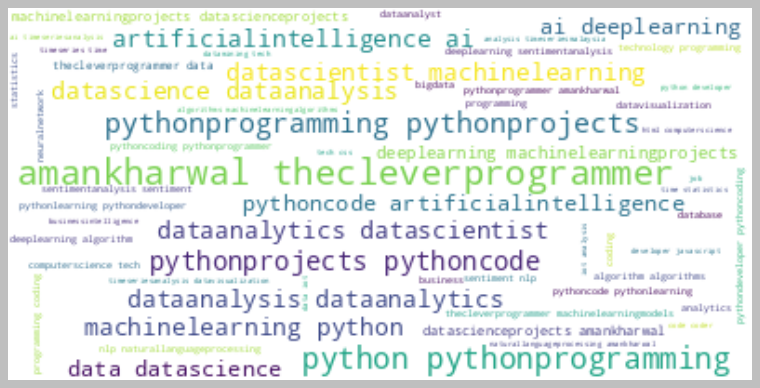

In [18]:
text = " ".join(i for i in data.Hashtags)
stopwords = set(STOPWORDS)
wordcloud = WordCloud(stopwords=stopwords, background_color="white").generate(text)
plt.figure( figsize=(12,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

# Analyzing Relationships

- Let’s analyze relationships to find the most important factors of our Instagram reach. It will also help us in understanding how the Instagram algorithm works.

- Let’s have a look at the relationship between the number of likes and the number of impressions on my Instagram posts:

In [19]:
figure = px.scatter(data_frame = data, x="Impressions",
                    y="Likes", size="Likes", trendline="ols",
                    title = "Relationship Between Likes and Impressions")
figure.show()

- There is a linear relationship between the number of likes and the reach I got on Instagram.

- Let’s see the relationship between the number of comments and the number of impressions on my Instagram posts:

In [20]:
figure = px.scatter(data_frame = data, x="Impressions",
                    y="Comments", size="Comments", trendline="ols",
                    title = "Relationship Between Comments and Total Impressions")
figure.show()

- It looks like the number of comments we get on a post doesn’t affect its reach.

- Let’s have a look at the relationship between the number of shares and the number of impressions:

In [21]:
figure = px.scatter(data_frame = data, x="Impressions",
                    y="Shares", size="Shares", trendline="ols",
                    title = "Relationship Between Shares and Total Impressions")
figure.show()

- There is a linear relationship between the number of times my post is saved and the reach of my Instagram post.

- Let’s have a look at the correlation of all the columns with the Impressions column:

This code will only calculate the correlation matrix for the numeric columns in your dataset, excluding the text columns like "Caption" and "Hashtags".

In [22]:
# Exclude non-numeric columns from correlation calculation
numeric_columns = data.select_dtypes(include=[np.number]).columns
correlation = data[numeric_columns].corr()
print(correlation["Impressions"].sort_values(ascending=False))


Impressions       1.000000
From Explore      0.893607
Follows           0.889363
Likes             0.849835
From Home         0.844698
Saves             0.779231
Profile Visits    0.760981
Shares            0.634675
From Other        0.592960
From Hashtags     0.560760
Comments         -0.028524
Name: Impressions, dtype: float64


In [23]:
# Check for non-numeric values in each numeric column
for column in numeric_columns:
    non_numeric_values = data[column][~data[column].apply(lambda x: str(x).replace('.', '').replace('-', '').isdigit())].unique()
    if len(non_numeric_values) > 0:
        print(f"Non-numeric values found in column '{column}':")
        print(non_numeric_values)
    else:
        print(f"No non-numeric values found in column '{column}'.")


No non-numeric values found in column 'Impressions'.
No non-numeric values found in column 'From Home'.
No non-numeric values found in column 'From Hashtags'.
No non-numeric values found in column 'From Explore'.
No non-numeric values found in column 'From Other'.
No non-numeric values found in column 'Saves'.
No non-numeric values found in column 'Comments'.
No non-numeric values found in column 'Shares'.
No non-numeric values found in column 'Likes'.
No non-numeric values found in column 'Profile Visits'.
No non-numeric values found in column 'Follows'.


- So we can say that more likes and saves will help you get more reach on Instagram.

- The higher number of shares will also help you get more reach, but a low number of shares will not affect your reach either.

# Analyzing Conversion Rate

- In Instagram, conversation rate means how many followers you are getting from the number of profile visits from a post.

- The formula that you can use to calculate conversion rate is (Follows/Profile Visits) * 100. Now let’s have a look at the conversation rate of my Instagram account:


In [24]:
conversion_rate = (data["Follows"].sum() / data["Profile Visits"].sum()) * 100
print(conversion_rate)

41.00265604249668


- So the conversation rate of my Instagram account is 31% which sounds like a very good conversation rate.

- Let’s have a look at the relationship between the total profile visits and the number of followers gained from all profile visits:

In [25]:
figure = px.scatter(data_frame = data, x="Profile Visits",
                    y="Follows", size="Follows", trendline="ols",
                    title = "Relationship Between Profile Visits and Followers Gained")
figure.show()

#### The relationship between profile visits and followers gained is also linear.

In [26]:
# Check Mounted or Not
# If not mounted -> ask mount
# If mounted -> ask unmount

In [27]:
###

In [28]:
# ============================================================
# Cell 1 - Feature Selection
# ============================================================

features = [

    "Likes",
    "Comments",
    "Shares",
    "Saves",
    "Profile Visits"

]

target = "Impressions"

X = data[features]

y = data[target]

print("✅ Features Selected")

print(features)

print("\n✅ Target Selected")

print(target)

✅ Features Selected
['Likes', 'Comments', 'Shares', 'Saves', 'Profile Visits']

✅ Target Selected
Impressions


In [29]:
# ============================================================
# Cell 2 - Train Test Split
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42

)

print("✅ Train Test Split Completed")

print("X_train :", X_train.shape)

print("X_test  :", X_test.shape)

✅ Train Test Split Completed
X_train : (95, 5)
X_test  : (24, 5)


In [30]:
# ============================================================
# Cell 3 - Train Model
# ============================================================

from sklearn.linear_model import PassiveAggressiveRegressor

model = PassiveAggressiveRegressor(

    random_state=42,

    max_iter=1000

)

model.fit(

    X_train,

    y_train

)

print("✅ Model Training Completed")

✅ Model Training Completed


In [32]:
# ============================================================
# Cell 4 - Model Evaluation
# ============================================================

from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error

predictions = model.predict(

    X_test

)

r2 = r2_score(

    y_test,

    predictions

)

mae = mean_absolute_error(

    y_test,

    predictions

)

print("=" * 60)

print("📊 MODEL PERFORMANCE")

print("=" * 60)

print("R2 Score :", round(r2,4))

print("MAE      :", round(mae,4))

📊 MODEL PERFORMANCE
R2 Score : 0.8123
MAE      : 1284.9836


In [34]:
# ============================================================
# Cell 5 - Save Model
# ============================================================

from joblib import dump

dump(

    model,

    "instagram_reach_model_v1.pkl"

)

print("✅ Model Saved Successfully!")

✅ Model Saved Successfully!


In [36]:
# ============================================================
# Cell 6 - Dynamic User Input
# ============================================================

default_likes = 100
default_comments = 10
default_shares = 15
default_saves = 20
default_profile_visits = 50

print("=" * 60)

print("🚀 INSTAGRAM REACH PREDICTION")

print("=" * 60)

likes = input(
    f"Likes [{default_likes}] : "
)

comments = input(
    f"Comments [{default_comments}] : "
)

shares = input(
    f"Shares [{default_shares}] : "
)

saves = input(
    f"Saves [{default_saves}] : "
)

profile_visits = input(
    f"Profile Visits [{default_profile_visits}] : "
)

🚀 INSTAGRAM REACH PREDICTION
Likes [100] : 100
Comments [10] : 10
Shares [15] : 15
Saves [20] : 20
Profile Visits [50] : 50


In [37]:
# ============================================================
# Cell 7 - Default Handling
# ============================================================

likes = int(likes) if likes else default_likes

comments = int(comments) if comments else default_comments

shares = int(shares) if shares else default_shares

saves = int(saves) if saves else default_saves

profile_visits = (

    int(profile_visits)

    if profile_visits

    else default_profile_visits

)

In [38]:
# ============================================================
# Cell 8 - Predict Reach
# ============================================================

prediction = model.predict([[
    likes,
    comments,
    shares,
    saves,
    profile_visits
]])

print("\n")

print("=" * 60)

print("🎯 INSTAGRAM REACH PREDICTION")

print("=" * 60)

print(f"Likes          : {likes}")

print(f"Comments       : {comments}")

print(f"Shares         : {shares}")

print(f"Saves          : {saves}")

print(f"Profile Visits : {profile_visits}")

print("\n")

print(
    f"📈 Predicted Reach : "
    f"{int(prediction[0])} Impressions"
)

print("=" * 60)



🎯 INSTAGRAM REACH PREDICTION
Likes          : 100
Comments       : 10
Shares         : 15
Saves          : 20
Profile Visits : 50


📈 Predicted Reach : 3392 Impressions


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but PassiveAggressiveRegressor was fitted with feature names



In [39]:
# ============================================================
# GOOGLE DRIVE SMART MOUNT 🚀
# ============================================================

import os

if os.path.exists("/content/drive/MyDrive"):

    print("✅ Google Drive Already Mounted!")

else:

    from google.colab import drive

    drive.mount("/content/drive")

    print("✅ Google Drive Mounted Successfully!")

Mounted at /content/drive
✅ Google Drive Mounted Successfully!


In [40]:
# ============================================================
# TRAIN FINAL MODEL 🚀
# ============================================================

from sklearn.linear_model import PassiveAggressiveRegressor

model = PassiveAggressiveRegressor(
    random_state=42,
    max_iter=1000
)

model.fit(
    X,
    y
)

print("✅ Final Model Trained Successfully!")

✅ Final Model Trained Successfully!


In [41]:
# ============================================================
# SAVE MODEL WITH AUTO VERSIONING 🚀
# ============================================================

import os
import re
import glob
from joblib import dump
from datetime import datetime

save_base_path = (
    "/content/drive/MyDrive/"
    "2026 Hands On/ML-Folder ✅/"
    "Experimental-Models ✅"
)

os.makedirs(
    save_base_path,
    exist_ok=True
)

model_base_name = "instagram_reach_model"

existing_model_files = glob.glob(

    os.path.join(
        save_base_path,
        f"{model_base_name}_v*.pkl"
    )

)

def get_next_version(
    file_list,
    base_name
):

    versions = []

    for file in file_list:

        filename = os.path.basename(file)

        match = re.search(

            rf"{base_name}_v(\d+)",

            filename

        )

        if match:

            versions.append(

                int(match.group(1))

            )

    return max(versions)+1 if versions else 1


next_version = get_next_version(

    existing_model_files,

    model_base_name

)

model_filename = os.path.join(

    save_base_path,

    f"{model_base_name}_v{next_version}.pkl"

)

dump(
    model,
    model_filename
)

print("✅ MODEL SAVED!")

print(model_filename)

print(
    f"Version : v{next_version}"
)

print(
    datetime.now()
)

✅ MODEL SAVED!
/content/drive/MyDrive/2026 Hands On/ML-Folder ✅/Experimental-Models ✅/instagram_reach_model_v1.pkl
Version : v1
2026-06-03 12:16:28.742798


In [52]:
# ============================================================
# Final Cell - Auto Detect Mount Status + Smart Flow 🚀
# ============================================================

import os
from google.colab import drive

# ============================================================
# STEP 1 - SYSTEM HEADER
# ============================================================

print("=" * 70)
print("🚀 SMART GOOGLE DRIVE AUTO MANAGER")
print("=" * 70)

# ============================================================
# STEP 2 - CHECK CURRENT MOUNT STATUS
# ============================================================

mount_path = "/content/drive"

is_mounted = os.path.exists("/content/drive/MyDrive")

# ============================================================
# STEP 3 - DISPLAY CURRENT STATUS
# ============================================================

print("\n📋 CHECKING GOOGLE DRIVE STATUS...\n")

if is_mounted:

    print("✅ Google Drive is ALREADY MOUNTED")
    print(f"📂 Mount Path: {mount_path}")

else:

    print("❌ Google Drive is NOT MOUNTED")

# ============================================================
# STEP 4 - IF DRIVE NOT MOUNTED
# ============================================================

if not is_mounted:

    print("\n" + "=" * 70)
    print("🧠 MOUNT OPTION")
    print("=" * 70)

    print("""
👉 Press ENTER directly → Skip mounting
👉 Type YES → Mount Google Drive
👉 Type NO → Skip mounting
""")

    # --------------------------------------------------------
    # INPUT
    # --------------------------------------------------------

    print("🔷 Do you want to mount Google Drive? (yes/no):")

    user_choice = input().strip().lower()

    # --------------------------------------------------------
    # DEFAULT OPTION
    # --------------------------------------------------------

    if user_choice == "":

        user_choice = "no"

        print("\n✅ DEFAULT OPTION SELECTED!")

    # --------------------------------------------------------
    # YES → MOUNT
    # --------------------------------------------------------

    if user_choice == "yes":

        print("\n🚀 STARTING GOOGLE DRIVE MOUNT...\n")

        try:

            drive.mount('/content/drive')

            print("\n✅ Google Drive mounted successfully!")

        except Exception as e:

            print("\n⚠️ ERROR DURING MOUNT!")
            print(e)

    # --------------------------------------------------------
    # NO → SKIP
    # --------------------------------------------------------

    elif user_choice == "no":

        print("\n✅ MOUNT PROCESS SKIPPED!")
        print("📂 Google Drive remains disconnected.")

    # --------------------------------------------------------
    # INVALID INPUT
    # --------------------------------------------------------

    else:

        print("\n⚠️ INVALID INPUT DETECTED!")
        print("✅ SAFE MODE ACTIVATED")
        print("📂 Skipping mount process.")

# ============================================================
# STEP 5 - IF DRIVE ALREADY MOUNTED
# ============================================================

else:

    print("\n" + "=" * 70)
    print("🧠 UNMOUNT OPTION")
    print("=" * 70)

    print("""
👉 Press ENTER directly → Keep mounted
👉 Type YES → Unmount Google Drive
👉 Type NO → Skip unmount
""")

    # --------------------------------------------------------
    # INPUT
    # --------------------------------------------------------

    print("🔷 Do you want to unmount Google Drive? (yes/no):")

    user_choice = input().strip().lower()

    # --------------------------------------------------------
    # DEFAULT OPTION
    # --------------------------------------------------------

    if user_choice == "":

        user_choice = "no"

        print("\n✅ DEFAULT OPTION SELECTED!")

    # --------------------------------------------------------
    # YES → UNMOUNT
    # --------------------------------------------------------

    if user_choice == "yes":

        print("\n🛑 STARTING GOOGLE DRIVE UNMOUNT...\n")

        try:

            drive.flush_and_unmount()

            print("\n✅ Google Drive unmounted successfully!")

        except Exception as e:

            print("\n⚠️ ERROR DURING UNMOUNT!")
            print(e)

    # --------------------------------------------------------
    # NO → SKIP
    # --------------------------------------------------------

    elif user_choice == "no":

        print("\n✅ UNMOUNT PROCESS SKIPPED!")
        print("📂 Google Drive remains connected.")

    # --------------------------------------------------------
    # INVALID INPUT
    # --------------------------------------------------------

    else:

        print("\n⚠️ INVALID INPUT DETECTED!")
        print("✅ SAFE MODE ACTIVATED")
        print("📂 Skipping unmount process.")

# ============================================================
# STEP 6 - FINAL STATUS CHECK
# ============================================================

print("\n" + "=" * 70)
print("🚀 FINAL STATUS")
print("=" * 70)

final_status = os.path.exists("/content/drive/MyDrive")

if final_status:

    print("""
✅ FINAL STATUS:
Google Drive is CONNECTED
""")

else:

    print("""
❌ FINAL STATUS:
Google Drive is DISCONNECTED
""")

print("=" * 70)
print("✅ PROCESS FINISHED")
print("=" * 70)

🚀 SMART GOOGLE DRIVE AUTO MANAGER

📋 CHECKING GOOGLE DRIVE STATUS...

✅ Google Drive is ALREADY MOUNTED
📂 Mount Path: /content/drive

🧠 UNMOUNT OPTION

👉 Press ENTER directly → Keep mounted
👉 Type YES → Unmount Google Drive
👉 Type NO → Skip unmount

🔷 Do you want to unmount Google Drive? (yes/no):
no

✅ UNMOUNT PROCESS SKIPPED!
📂 Google Drive remains connected.

🚀 FINAL STATUS

✅ FINAL STATUS:
Google Drive is CONNECTED

✅ PROCESS FINISHED


In [53]:
# ============================================================
# SHOW FILES INSIDE YOUR TARGET FOLDER 🚀
# ============================================================

import os
import pandas as pd
from IPython.display import display

target_path = (
    "/content/drive/MyDrive/"
    "2026 Hands On/ML-Folder ✅/Experimental-Models ✅"
)

files = []

for item in os.listdir(target_path):

    full_path = os.path.join(
        target_path,
        item
    )

    files.append({

        "File Name": item,

        "Type":
        "Folder"
        if os.path.isdir(full_path)
        else "File",

        "Size (KB)":
        round(
            os.path.getsize(full_path) / 1024,
            2
        ) if os.path.isfile(full_path)
        else "-"

    })

df = pd.DataFrame(files)

df.insert(
    0,
    "S.No",
    range(1, len(df) + 1)
)

display(df)

,S.No,File Name,Type,Size (KB)
0,1,tfidf_vectorizer_v1.pkl,File,178.16
1,2,processed_df_v1.parquet,File,2353.06
2,3,svd_model_v1.pkl,File,10486.03
3,4,svd_model_v2.pkl,File,10486.03
4,5,svd_model_v3.pkl,File,10486.03
5,6,instagram_reach_model_v1.pkl,File,1.13


In [54]:
save_base_path = (
    "/content/drive/MyDrive/"
    "2026 Hands On/ML-Folder ✅/"
    "Experimental-Models ✅"
)
print(save_base_path)

/content/drive/MyDrive/2026 Hands On/ML-Folder ✅/Experimental-Models ✅


# Download Latest Model

In [63]:
# ============================================================
# DOWNLOAD LATEST INSTAGRAM MODEL TO COLAB 🚀
# ============================================================

import os
import re
import glob
import shutil

# ============================================================
# DRIVE PATH
# ============================================================

save_base_path = (
    "/content/drive/MyDrive/"
    "2026 Hands On/ML-Folder ✅/"
    "Experimental-Models ✅"
)

# ============================================================
# FIND LATEST MODEL
# ============================================================

model_files = glob.glob(
    os.path.join(
        save_base_path,
        "instagram_reach_model_v*.pkl"
    )
)

if len(model_files) == 0:

    raise FileNotFoundError(
        "❌ No Instagram Models Found!"
    )

latest_file = max(
    model_files,
    key=lambda x: int(
        re.search(
            r"instagram_reach_model_v(\d+)",
            os.path.basename(x)
        ).group(1)
    )
)

# ============================================================
# MODEL NAME
# ============================================================

latest_model_name = os.path.basename(
    latest_file
)

# ============================================================
# COLAB DESTINATION
# ============================================================

colab_model_path = os.path.join(
    "/content",
    latest_model_name
)

print("=" * 70)
print("🚀 INSTAGRAM MODEL CHECK")
print("=" * 70)

print(f"""
📄 Latest Model Found:

{latest_model_name}

📂 Drive Path:

{latest_file}
""")

# ============================================================
# CHECK ALREADY EXISTS
# ============================================================

if os.path.exists(colab_model_path):

    print("✅ MODEL ALREADY EXISTS IN COLAB")

    print(f"""
📍 Colab Path:

{colab_model_path}

⏭️ Download Skipped
""")

else:

    print("⬇️ DOWNLOADING MODEL TO COLAB...\n")

    shutil.copy(
        latest_file,
        colab_model_path
    )

    print("✅ DOWNLOAD COMPLETED!")

    print(f"""
📍 Saved To:

{colab_model_path}
""")

# ============================================================
# FINAL STATUS
# ============================================================

print("=" * 70)
print("🚀 FINAL STATUS")
print("=" * 70)

print(f"""
✅ Ready For Loading

📄 Model:

{latest_model_name}

📍 Colab Location:

{colab_model_path}
""")

print("=" * 70)

🚀 INSTAGRAM MODEL CHECK

📄 Latest Model Found:

instagram_reach_model_v1.pkl

📂 Drive Path:

/content/drive/MyDrive/2026 Hands On/ML-Folder ✅/Experimental-Models ✅/instagram_reach_model_v1.pkl

✅ MODEL ALREADY EXISTS IN COLAB

📍 Colab Path:

/content/instagram_reach_model_v1.pkl

⏭️ Download Skipped

🚀 FINAL STATUS

✅ Ready For Loading

📄 Model:

instagram_reach_model_v1.pkl

📍 Colab Location:

/content/instagram_reach_model_v1.pkl



# Load Latest Model Automatically

In [66]:
# ============================================================
# LOAD LATEST INSTAGRAM MODEL AUTOMATICALLY 🚀
# ============================================================

from joblib import load

loaded_model = load(
    colab_model_path
)

print("=" * 70)
print("🚀 MODEL LOAD SUMMARY")
print("=" * 70)

print(f"""
✅ Model Loaded Successfully

📄 Model:
{os.path.basename(colab_model_path)}

📍 Path:
{colab_model_path}
""")

print("=" * 70)

🚀 MODEL LOAD SUMMARY

✅ Model Loaded Successfully

📄 Model:
instagram_reach_model_v1.pkl

📍 Path:
/content/instagram_reach_model_v1.pkl



# Dynamic User Input

In [67]:
# ============================================================
# INSTAGRAM REACH PREDICTION 🚀
# ============================================================

import pandas as pd
from IPython.display import display

# ============================================================
# DEFAULT VALUES
# ============================================================

default_likes = 100
default_comments = 10
default_shares = 15
default_saves = 20
default_profile_visits = 50

# ============================================================
# USER INPUT SECTION
# ============================================================

print("=" * 70)
print("📱 INSTAGRAM REACH PREDICTION")
print("=" * 70)

print(f"""
📌 DEFAULT VALUES

👍 Likes           : {default_likes}
💬 Comments        : {default_comments}
🔁 Shares          : {default_shares}
📌 Saves           : {default_saves}
👤 Profile Visits  : {default_profile_visits}

👉 Press ENTER for defaults
👉 Or enter your own values
""")

likes = input("🔷 Likes:\n")
comments = input("🔷 Comments:\n")
shares = input("🔷 Shares:\n")
saves = input("🔷 Saves:\n")
profile_visits = input("🔷 Profile Visits:\n")

# ============================================================
# HANDLE DEFAULTS
# ============================================================

likes = int(likes) if likes.strip() else default_likes

comments = (
    int(comments)
    if comments.strip()
    else default_comments
)

shares = (
    int(shares)
    if shares.strip()
    else default_shares
)

saves = (
    int(saves)
    if saves.strip()
    else default_saves
)

profile_visits = (
    int(profile_visits)
    if profile_visits.strip()
    else default_profile_visits
)

# ============================================================
# PREDICT
# ============================================================

prediction = loaded_model.predict([[
    likes,
    comments,
    shares,
    saves,
    profile_visits
]])

predicted_reach = round(prediction[0])

# ============================================================
# RESULT TABLE
# ============================================================

results_df = pd.DataFrame({

    "Metric": [

        "Likes",
        "Comments",
        "Shares",
        "Saves",
        "Profile Visits",
        "Predicted Reach"

    ],

    "Value": [

        likes,
        comments,
        shares,
        saves,
        profile_visits,
        predicted_reach

    ]

})

print("\n")
print("=" * 70)
print("🎯 INSTAGRAM REACH PREDICTION RESULT")
print("=" * 70)

display(results_df)

print("\n✅ Prediction Completed Successfully!")

📱 INSTAGRAM REACH PREDICTION

📌 DEFAULT VALUES

👍 Likes           : 100
💬 Comments        : 10
🔁 Shares          : 15
📌 Saves           : 20
👤 Profile Visits  : 50

👉 Press ENTER for defaults
👉 Or enter your own values

🔷 Likes:

🔷 Comments:

🔷 Shares:

🔷 Saves:

🔷 Profile Visits:



🎯 INSTAGRAM REACH PREDICTION RESULT


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but PassiveAggressiveRegressor was fitted with feature names



,Metric,Value
0,Likes,100
1,Comments,10
2,Shares,15
3,Saves,20
4,Profile Visits,50
5,Predicted Reach,3742



✅ Prediction Completed Successfully!


# 🎯 Understanding Predicted Reach (Impressions)

When the model predicts:

Predicted Reach = 3742

it means that based on the values entered:

* Likes = 100
* Comments = 10
* Shares = 15
* Saves = 20
* Profile Visits = 50

the machine learning model estimates that the Instagram post may receive approximately:

3742 Impressions

## 📌 What Are Impressions?

Impressions represent the total number of times a post was displayed on users' screens.

Example:

* User A sees the post 3 times
* User B sees the post 2 times
* User C sees the post 1 time

Then:

* Reach = 3 users
* Impressions = 6 views

because the same user can view the post multiple times.

## 📌 Is This Real Instagram Data?

No.

This notebook is NOT connected to Instagram's live servers or APIs.

Instead, it uses a historical Instagram dataset to learn patterns and then predicts expected impressions based on user-provided engagement values.

Flow:

Historical Instagram Dataset
↓
Model Training
↓
User Inputs
↓
Predicted Impressions

Therefore:

Predicted Reach = 3742

is a machine learning estimate and not a live Instagram result.

## 📌 What Did The Model Learn?

The model learned patterns such as:

* More Likes → Higher Impressions
* More Shares → Higher Impressions
* More Saves → Higher Impressions
* More Profile Visits → Higher Impressions

Using these learned relationships, it estimates the expected impressions for new input values.

## 📌 Project Type

This project is:

Instagram Reach Prediction System

It predicts:

Expected Impressions (Reach Performance)

It is NOT:

Instagram Feed Recommendation System

A feed recommendation system would decide:

* Which posts to show User A
* Which reels to show User B
* Which content to recommend User C

similar to Instagram's actual recommendation engine.

## ✅ Final Conclusion

Predicted Reach = 3742 means:

Based on the engagement values entered, the model estimates that the Instagram post may receive approximately 3742 impressions (views) according to the patterns learned from the historical Instagram dataset.
